In [1]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

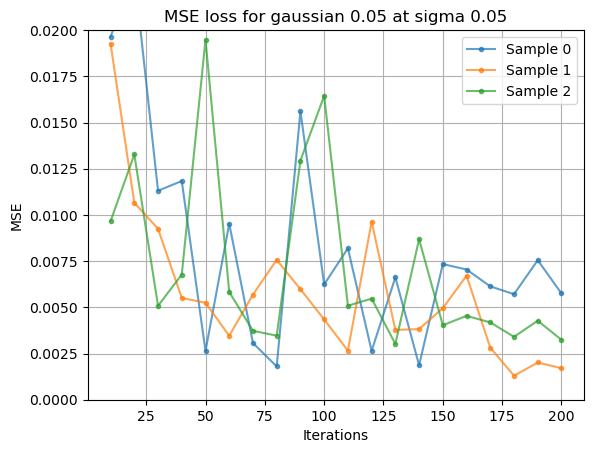

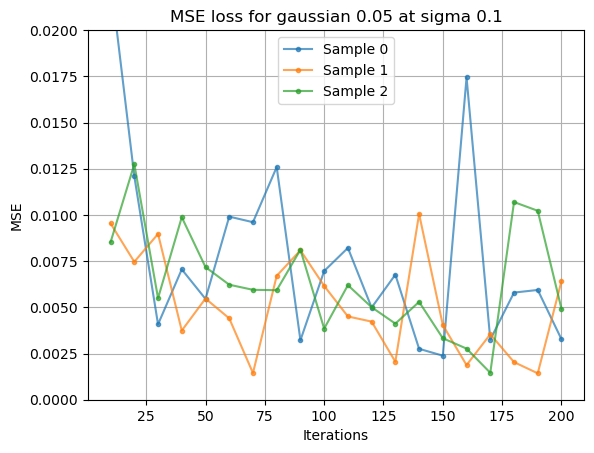

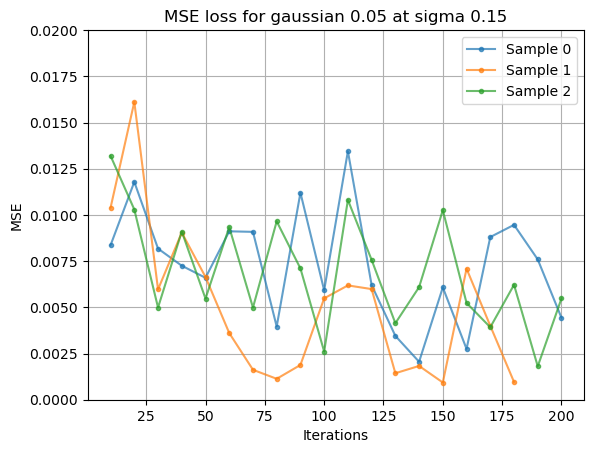

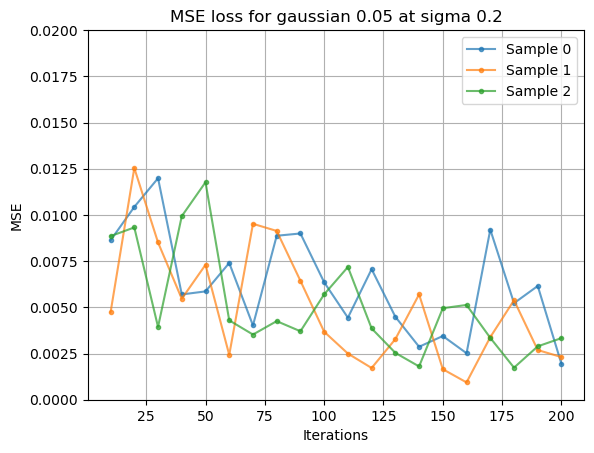

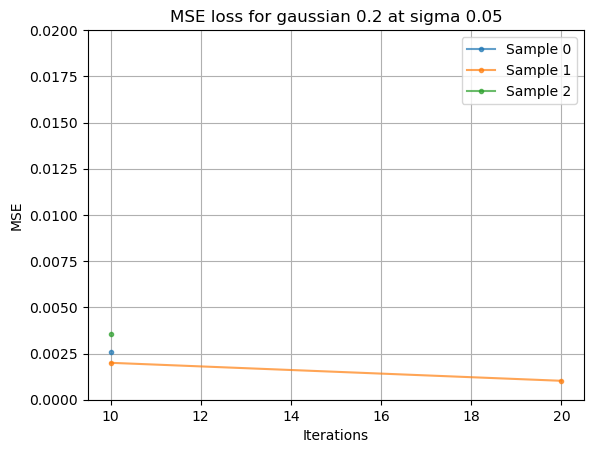

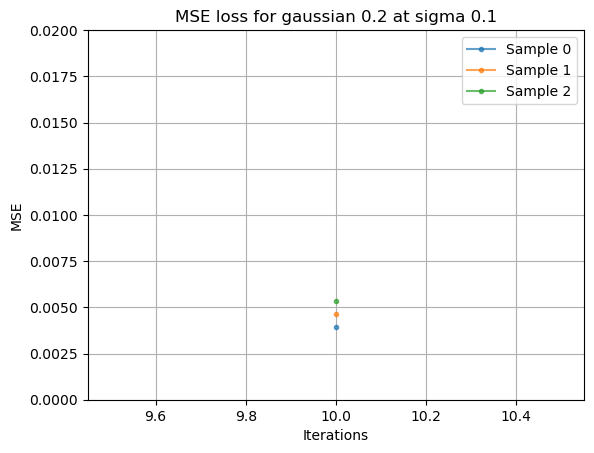

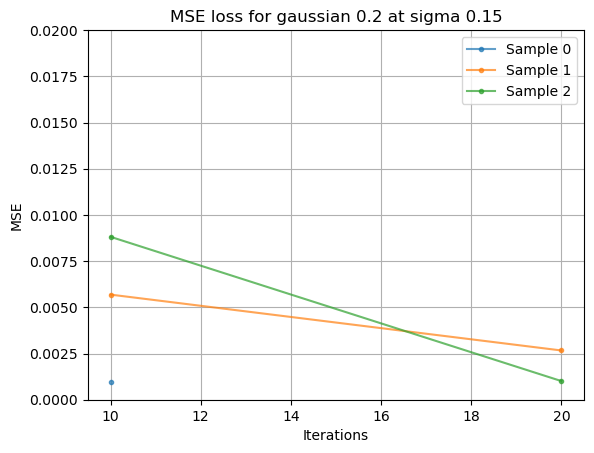

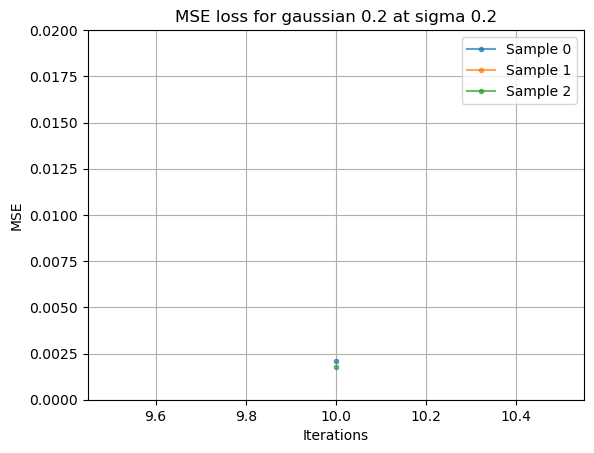

In [16]:
for g in [0.05, 0.2]:
    for sigma in [0.05, 0.10, 0.15, 0.20]:
        csv_path = f'../savings/lpn_cond_mrs_h_64_k_3_n_(0.05_0.2)/prior/mse_{g}_{sigma:.2f}.csv'
        df = pd.read_csv(csv_path)
        plt.plot(figsize = (14,7))
        for s in [0,1,2]:
            sample_df = df[df['sample'] == s]
            plt.plot(sample_df['iter'], sample_df['mse'], marker='o', markersize=3, alpha=0.7, label=f'Sample {s}')
        plt.xlabel('Iterations')
        plt.ylabel('MSE')
        plt.ylim((0,0.02))
        plt.legend()
        plt.title(f'MSE loss for gaussian {g} at sigma {sigma}')
        plt.grid()
        plt.show()

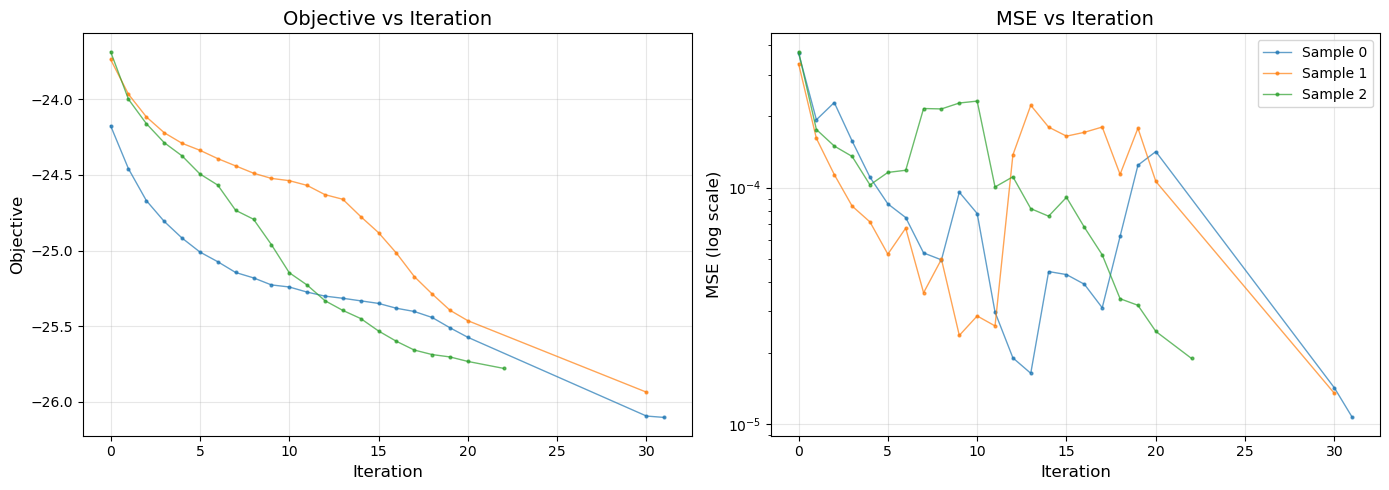

In [7]:
csv_path = f'../savings/lpn_cond_mrs_h_64_k_33_n_(0.05_0.2)/prior/mse_clean_0.05.csv'
df = pd.read_csv(csv_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Objective
ax1 = axes[0]

for s in [0,1,2]:
    sample_df = df[df['sample'] == s]
    ax1.plot(sample_df['iter'].values, sample_df['objective'].values, 
             marker='o', markersize=2, linewidth=1, alpha=0.7, label=f'Sample {s}')
    
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Objective', fontsize=12)
ax1.set_title('Objective vs Iteration', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot MSE
ax2 = axes[1]

for s in [0,1,2]:
    sample_df = df[df['sample'] == s]
    ax2.plot(sample_df['iter'].values, sample_df['mse'].values, 
             marker='o', markersize=2, linewidth=1, alpha=0.7, label=f'Sample {s}')
    
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('MSE (log scale)', fontsize=12)
ax2.set_title('MSE vs Iteration', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()